In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings

warnings.filterwarnings("ignore")

In [19]:
# outlyairs == these are the extreme values in data set 
salary =  [11,23,45,66,78,98,100,2,45,65,76,35,75,34,1,160]
salary

[11, 23, 45, 66, 78, 98, 100, 2, 45, 65, 76, 35, 75, 34, 1, 160]

In [20]:
np.quantile(salary,[0,0.25,0.50,0.75,1])

array([  1.  ,  31.25,  55.  ,  76.5 , 160.  ])

In [21]:
df = pd.DataFrame(salary,columns=["salary"])
df

,salary
0,11
1,23
2,45
3,66
4,78
5,98
6,100
7,2
8,45
9,65


In [22]:
df.describe()

,salary
count,16.000000
mean,57.125000
std,41.748253
min,1.000000
25%,31.250000
50%,55.000000
75%,76.500000
max,160.000000


Text(0.5, 1.0, 'box plot')

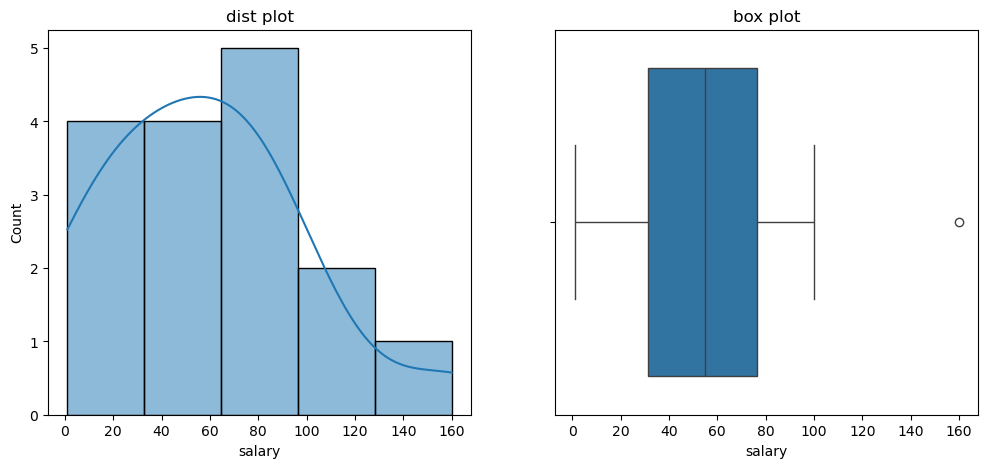

In [24]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df["salary"],kde=True)
plt.title("dist plot")

plt.subplot(1,2,2)
sns.boxplot(data=df,x="salary")
plt.title("box plot")

In [25]:
# here distribution is skewed then outlier is present at one side 

# droping  the outlier
# to treat outlier we will use mean and median 

In [27]:
# droping outliers 

Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)

IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

In [32]:
data_filtered = df[(df.salary >= lower_fence) & (df.salary <= upper_fence)]
data_filtered

,salary
0,11
1,23
2,45
3,66
4,78
5,98
6,100
7,2
8,45
9,65


Text(0.5, 1.0, 'box plot')

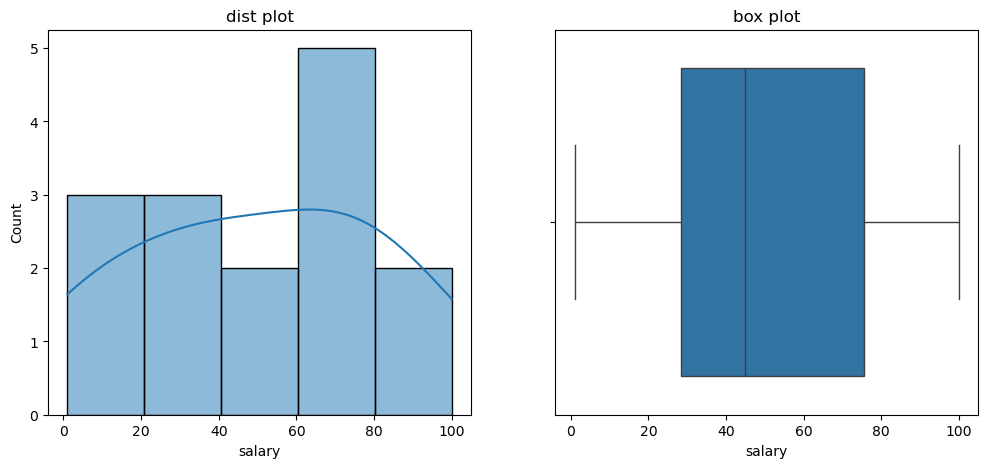

In [34]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data_filtered["salary"],kde=True)
plt.title("dist plot")

plt.subplot(1,2,2)
sns.boxplot(data=data_filtered,x="salary")
plt.title("box plot")

In [36]:
# impotation with mean and median 

df["salary_imputed_mean"] = np.where((df.salary >= upper_fence) | (df.salary <= lower_fence) , df["salary"].mean(),df["salary"])

In [38]:
df

,salary,salary_imputed_mean
0,11,11.000
1,23,23.000
2,45,45.000
3,66,66.000
4,78,78.000
5,98,98.000
6,100,100.000
7,2,2.000
8,45,45.000
9,65,65.000


In [39]:
# capping with outlier  # capping --> replacing with nearest value which is not outlier